# QUBO v2 — fetal hematopoiesis (Ranzoni et al. 2021)

Same Eq. (4) solver as v1 (`qubo_model.py`), on **Smart-seq2** fetal liver / bone marrow
from the Cvejic GitLab clone — not GEO GSE308682.

$$
\min_{F} \left[ -\alpha \sum_{i} I_{i} F_{i} + (1-\alpha)\sum_{i,j} R_{ij} F_{i} F_{j} \right], \quad Q = (1-\alpha)R - \alpha\,\mathrm{diag}(I)
$$

| | v1 | v2 |
| --- | --- | --- |
| Data | GSE308682 10x UMI | Ranzoni fetal Smart-seq2 |
| X | Pearson residuals | log1p(CPM) (default) |
| T | DPT, iroot = min HBE1 | published PAGA dpt (HSC/MPP root) |
| Cells | ~10,691 QC | ~4,463 hematopoietic |

Set **`QUBO_V2_DATA_DIR`** to the GitLab repo root (or `Data/ScanpyObjets`).
Kaiwu tabu needs **Python 3.10**. Default **`SMOKE = False`** is the k=50 / 5,000-HVG benchmark (same cost class as v1). Set **`SMOKE = True`** only for a 200-cell / 80-gene check.

Details: [`v2/README.md`](README.md).

In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys
from pathlib import Path

print(f"Kernel Python {sys.version.split()[0]}  (Kaiwu official wheel needs 3.10.x)")
if sys.version_info[:2] != (3, 10):
    raise SystemExit(
        f"Need Python 3.10.x for Kaiwu (got {sys.version.split()[0]}). "
        "Select kernel Python 3.10 (Kaiwu)."
    )

V2_DIR = Path.cwd() if (Path.cwd() / "foetal_loader.py").exists() else Path.cwd() / "v2"
REPO = V2_DIR.parent if V2_DIR.name == "v2" else Path.cwd()
os.environ.setdefault("QUBO_REPO_DIR", str(REPO))
os.environ["QUBO_V2_DATA_DIR"] = "/Users/jinshang/Projects/integrative-scrna-scatac-human-foetal"

for p in (REPO, V2_DIR):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

import numpy as np
from qubo_model import (
    HAS_DWAVE,
    HAS_KAIWU,
    HAS_TABU,
    available_solvers,
    compute_mutual_information_matrix,
    solve_qubo_target_k,
    solver_banner,
)
from experiment import (
    compare_kaiwu_tabu_on_same_q,
    compare_with_lasso_rfr,
    load_experiment,
    print_regression_mse,
    target_cardinality,
)

print(f"Repo {REPO}")
print(f"v2   {V2_DIR}")
print(f"QUBO_V2_DATA_DIR={os.environ.get('QUBO_V2_DATA_DIR')}")
print(f"Ocean tabu={HAS_TABU}, Ocean SA={HAS_DWAVE}, Kaiwu SDK={HAS_KAIWU}")

Kernel Python 3.10.21  (Kaiwu official wheel needs 3.10.x)
Repo /Users/jinshang/Projects/qubo
v2   /Users/jinshang/Projects/qubo/v2
QUBO_V2_DATA_DIR=/Users/jinshang/Projects/integrative-scrna-scatac-human-foetal
Ocean tabu=True, Ocean SA=True, Kaiwu SDK=True


## Flags

`SMOKE=False` is the full benchmark (pairwise MI at p=5000, same cost class as v1).
`SMOKE=True` subsamples the **real** h5ad (fast). Kaiwu-on-same-Q runs when smoke is off.

In [2]:
import qubo_model as _qubo_model

SMOKE = False                # True → 200 cells × 80 HVGs, k=10 smoke check
USE_REAL_DATA = True
N_TOP_GENES = 80 if SMOKE else 5000
N_CELLS = 200 if SMOKE else None
TRANSFORM = "log"            # log | pearson
TARGET_MODE = "paga_dpt"     # paga_dpt | dpt | gene
ROOT_GENE = "MLLT3"
SOLVER = "tabu"
COMPARE_KAIWU_TABU = not SMOKE
K_TARGET = 10 if SMOKE else 50

print(solver_banner(SOLVER))
print("qubo_model loaded from", _qubo_model.__file__)
print(f"SMOKE={SMOKE}  n_top_genes={N_TOP_GENES}  n_cells={N_CELLS}  transform={TRANSFORM}")
print("Available solvers:")
for name, meta in available_solvers().items():
    mark = "yes" if meta["installed"] else "no"
    print(f"  {name:12} installed={mark:3}  {meta['kind']:16}  {meta['stack']}")

X, y, true_features, feature_names, meta = load_experiment(
    use_real_data=USE_REAL_DATA,
    n_top_genes=N_TOP_GENES,
    transform=TRANSFORM,
    target_mode=TARGET_MODE,
    root_gene=ROOT_GENE,
    n_cells=N_CELLS,
)

D-Wave Ocean TabuSampler (classical, local; MATLAB tabu analog)
qubo_model loaded from /Users/jinshang/Projects/qubo/qubo_model.py
SMOKE=False  n_top_genes=5000  n_cells=None  transform=log
Available solvers:
  tabu         installed=yes  classical         dwave-ocean-sdk
  sa           installed=yes  classical         dwave-ocean-sdk
  leap         installed=yes  quantum-hybrid    dwave-ocean-sdk
  custom_sa    installed=yes  classical         this repo
  kaiwu_sa     installed=yes  classical         kaiwu SDK
  kaiwu_tabu   installed=yes  classical         kaiwu SDK
  kaiwu_cim    installed=yes  quantum           kaiwu CIM (QBoson photonic); kaiwu-pytorch-plugin optional
Loading counts: /Users/jinshang/Projects/integrative-scrna-scatac-human-foetal/Data/ScanpyObjets/MergedAllSamples.h5ad
Loading PAGA / dpt: /Users/jinshang/Projects/integrative-scrna-scatac-human-foetal/Data/ScanpyObjets/MergedAllSamples_PAGA.h5ad
Hematopoietic cells: 4463 × 48292 genes (PAGA n=4463)
After min_cells=1

HVG log-CPM variance: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 37/37 [00:00<00:00, 70.80it/s]


Computing log1p(CPM)...
Target T: published PAGA dpt_pseudotime (HSC/MPP root)
X=(4463, 5000) (log1p(CPM)), clusters=HSC-MPPs=1200, Pre-B cells=322, MEMPs-Cycle=255, Erythroid cells=254, Pro-B cells=230, Mature B cells=204, Monocytes 1=201, Mast cells=200, ...
Fetal Smart-seq2 (log1p(CPM)): X=(4463, 5000), y=(4463,)
Feature names (first 10): ['HBG2', 'MPO', 'FOS', 'CD74', 'IGHM (ENSG00000211899)', 'HLA-DRA (ENSG00000204287)', 'HSP90AB1', 'LDHA', 'HIST1H4C', 'STMN1']


In [3]:
I, R = compute_mutual_information_matrix(X, y, n_bins=10)
print(f"Importance I (first 5): {I[:5]}")
print(f"Redundancy R (5x5):\n{R[:5, :5]}")

Redundancy R (pairwise MI): 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5000/5000 [01:35<00:00, 52.54it/s]

Importance I (first 5): [0.09936743 0.15335427 0.22843257 0.36070084 0.15333692]
Redundancy R (5x5):
[[0.         0.03330454 0.03649069 0.03990808 0.01104264]
 [0.03330454 0.         0.03310734 0.05831809 0.0664412 ]
 [0.03649069 0.03310734 0.         0.05643008 0.02664869]
 [0.03990808 0.05831809 0.05643008 0.         0.21647779]
 [0.01104264 0.0664412  0.02664869 0.21647779 0.        ]]


In [4]:
K = target_cardinality(X.shape[1], k=K_TARGET)
print(f"Target cardinality K={K}")

Target cardinality K=50


In [5]:
selected_features_qubo, energy, alpha, Q, report = solve_qubo_target_k(
    I, R, k=K, solver=SOLVER
)
selected_idx_qubo = np.where(selected_features_qubo == 1)[0]
print(f"α*={alpha:.4f}, energy={energy:.4f}, |F*|={len(selected_idx_qubo)}")
print(f"QUBO selected indices: {selected_idx_qubo}")
if feature_names is not None:
    print("QUBO selected genes:", [feature_names[i] for i in selected_idx_qubo])

kaiwu_idx = None
if COMPARE_KAIWU_TABU:
    kaiwu_idx = compare_kaiwu_tabu_on_same_q(
        Q,
        selected_features_qubo,
        energy,
        k=K,
        feature_names=feature_names,
    )

Bisect α for |F*|≈k:   0%|                                                                                                                                                              | 0/16 [00:00<?, ?it/s]

TabuSampler: n=5000, num_reads=2, timeout=10000 ms/read (Ocean default is 20 ms), first initial state = all zeros


Bisect α for |F*|≈k:   6%|███████▎                                                                                                            | 1/16 [00:21<05:16, 21.10s/it, E=-4.97, alpha=0.5000, n_sel=154]

  α-bisect 1/16: α=0.500000  |F*|=154  energy=-4.9721  |n-k|=104
TabuSampler: n=5000, num_reads=2, timeout=10000 ms/read (Ocean default is 20 ms), first initial state = all zeros


Bisect α for |F*|≈k:  12%|██████████████▋                                                                                                      | 2/16 [00:41<04:53, 20.95s/it, E=-1.02, alpha=0.2500, n_sel=68]

...

Bisect α for |F*|≈k:  94%|████████████████████████████████████████████████████████████████████████████████████████████████████████████▊       | 15/16 [05:13<00:21, 21.01s/it, E=-0.78, alpha=0.2188, n_sel=55]

  α-bisect 15/16: α=0.218781  |F*|=55  energy=-0.7775  |n-k|=5
TabuSampler: n=5000, num_reads=2, timeout=10000 ms/read (Ocean default is 20 ms), first initial state = all zeros


Bisect α for |F*|≈k: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 16/16 [05:34<00:00, 20.90s/it, E=-0.78, alpha=0.2188, n_sel=54]

  α-bisect 16/16: α=0.218765  |F*|=54  energy=-0.7775  |n-k|=4
  kept best_alpha=0.219238 (|n-k|=1, E=-0.7813)


TabuSampler: n=5000, num_reads=8, timeout=10000 ms/read (Ocean default is 20 ms), first initial state = all zeros
QUBO acceptance:
  |F*|=51  target k=50  tol=5
  energy reported=-0.7813  recomputed FᵀQF=-0.7813
  empty mask energy=0  best singleton Q[373,373]=-0.1080
  one-bit moves that would lower E: turn_off=0  turn_on=0
  PASS: energy beats empty/singleton and cardinality is near k.
α*=0.2192, energy=-0.7813, |F*|=51
QUBO selected indices: [   2   18   20   28  124  168  180  279  335  373  485  517  536  702
  741  878  916  992 1162 1196 1265 1278 1323 1606 1687 2108 2159 2335
 2409 2773 2937 3069 3458 3507 3566 3704 3783 3907 3910 4019 4076 4087
 4184 4197 4279 4368 4372 4481 4602 4844 4938]
QUBO selected genes: ['FOS', 'RPS18 (ENSG00000231500)', 'HBG1', 'SELL', 'SRGN', 'CD52', 'SPINK2', 'CD24', 'CYTL1', 'NPR3', 'S100A12', 'MLLT3', 'MS4A3', 'UBE2C', 'XIST', 'RETN', 'HOPX', 'FCN1', 'ALOX5 (ENSG00000012779)', 'ADAM28', 'CXCL8', 'CTSG', 'ADGRG1', 'DEPP1', 'PADI4 (ENSG00000159339)'

LASSO path: α=0.01078, n_nonzero=48 (target K=50)
Fitting random forest (100 trees)...

=== Feature selection (K=50) ===
QUBO:                [2, 18, 20, 28, 124, 168, 180, 279, 335, 373, 485, 517, 536, 702, 741, 878, 916, 992, 1162, 1196, 1265, 1278, 1323, 1606, 1687, 2108, 2159, 2335, 2409, 2773, 2937, 3069, 3458, 3507, 3566, 3704, 3783, 3907, 3910, 4019, 4076, 4087, 4184, 4197, 4279, 4368, 4372, 4481, 4602, 4844, 4938]
LASSO:               [6, 14, 15, 18, 19, 20, 22, 28, 32, 76, 80, 82, 94, 152, 153, 180, 219, 222, 254, 279, 335, 340, 373, 452, 485, 495, 517, 536, 789, 793, 916, 992, 1162, 1196, 1203, 1323, 1383, 1441, 1541, 1703, 1713, 2180, 2223, 2303, 2676, 2780, 3389, 3483]
Random forest:       [0, 1, 2, 3, 4, 12, 19, 20, 28, 31, 32, 39, 40, 76, 80, 82, 83, 85, 91, 110, 124, 148, 153, 168, 180, 183, 222, 279, 335, 373, 429, 495, 517, 534, 536, 681, 916, 1059, 1162, 1174, 1225, 1627, 1675, 1713, 1766, 3533, 3550, 3744, 3907, 4267]
Overlaps: Q∩L=15/50, Q∩RF=14/50, L∩RF=19/50, all3

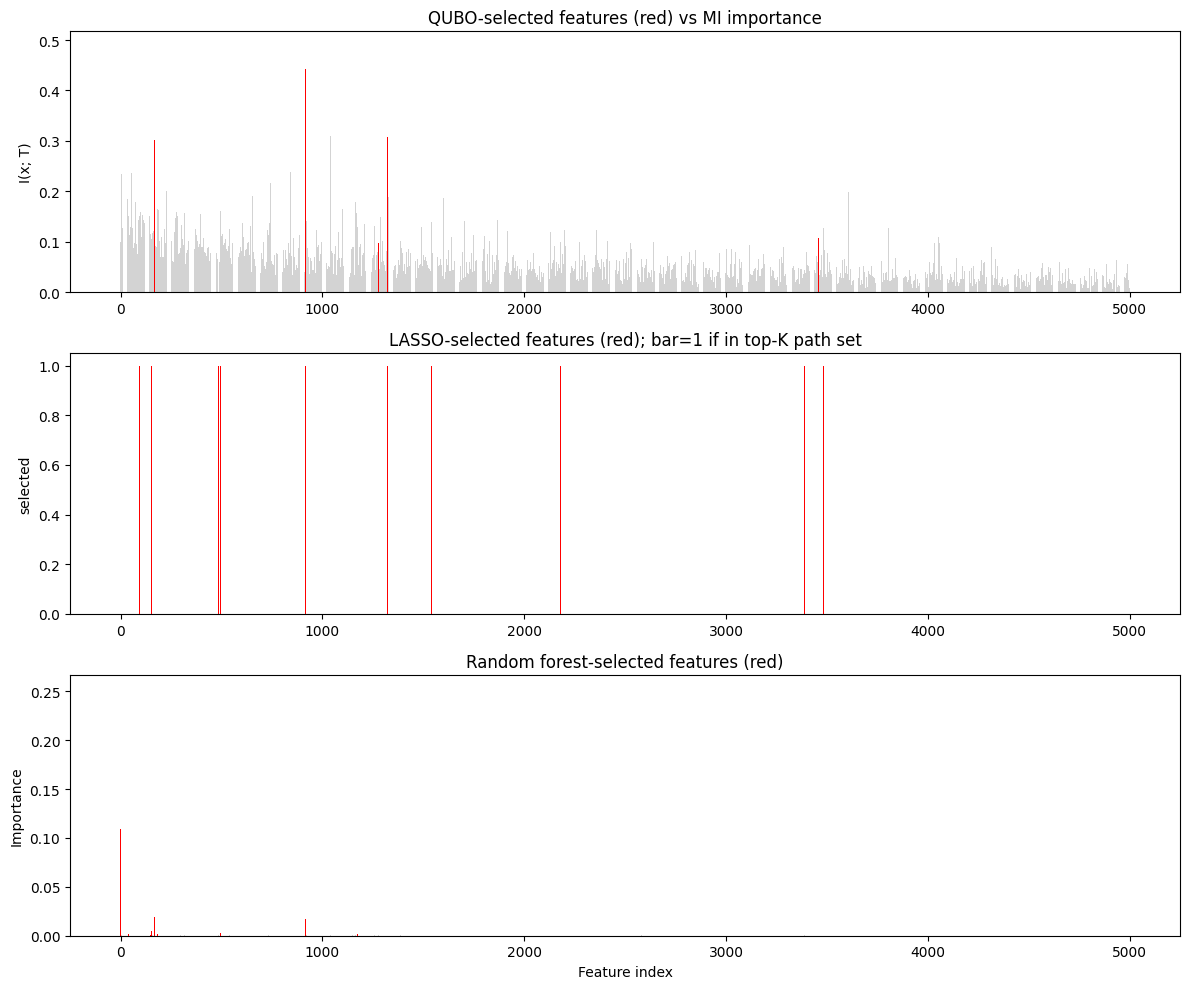

Regression MSE (z-scored Ridge α=1):
  QUBO Ocean tabu (k=51): 0.0060
  QUBO Kaiwu tabu (k=45): 0.0061
  LASSO (k=48): 0.0046
  RF (k=50): 0.0049
  All features: 0.0180


In [6]:
k_compare = K
if not report["accepted"]:
    print(
        "QUBO did not pass energy/cardinality acceptance. "
        f"LASSO and RF are compared at target K={K}, not |F*|={len(selected_idx_qubo)}."
    )
selected_idx_lasso, selected_idx_rf = compare_with_lasso_rfr(
    X, y, I, true_features, selected_idx_qubo, K=k_compare, feature_names=feature_names
)
extra = {}
if kaiwu_idx is not None:
    extra["QUBO Kaiwu tabu"] = kaiwu_idx
print_regression_mse(
    X, y, selected_idx_qubo, selected_idx_lasso, selected_idx_rf, extra=extra
)

## After a run

A healthy unconstrained Eq. (4) solve has **negative energy** and **|F\*| ≈ K** (50).
Kaiwu local tabu on the **same** $Q$ does not need a CIM key.

This notebook’s default is the full fetal matrix (`SMOKE=False`). Ridge MSE is a leaky 70/30 after selection, same as v1 — not independent generalization.